# 25: How Does Finite Computation Create Non-Local Coupling?

This notebook freezes the Chapter 24 supported n=1 regime and varies only lag-one evaluation capacity. It stops at Chapter 25.


In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "notebooks" / "_shared"))

from digital_crystal import (
    CrystalParams,
    advance_one_step,
    attachment_probability,
    axial_to_xy,
    cell_keyed_uniform,
    frontier,
    hex_distance,
    initial_state,
    neighbors,
    run_crystal,
)

NOTEBOOK_PROFILE = os.environ.get("NOTEBOOK_PROFILE", "quick")
RUN_CANONICAL = os.environ.get("RUN_CANONICAL", "0") in {"1", "true", "True"}

def load_json(path):
    return json.loads((ROOT / path).read_text(encoding="utf-8"))

def mean_of(summary, key="mean"):
    return summary[key] if isinstance(summary, dict) and key in summary else summary

def audit(label, observed, source="canonical research artifact"):
    return {"label": label, "source": source, "observed": observed}

def plot_cells(ax, occupied, lost=None, selected=None, title=""):
    lost = lost or set()
    selected = selected or set()
    for cells, color, size, alpha in [(occupied, "#253494", 18, .85), (lost, "#b2182b", 30, .9), (selected, "#fdae61", 45, .95)]:
        if cells:
            xy = np.array([axial_to_xy(c) for c in cells])
            ax.scatter(xy[:,0], xy[:,1], s=size, c=color, alpha=alpha)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(title)


## Slot conservation identity


In [2]:
B = 5
S_force = set(range(B))
S_prevent = set(range(2, 2+B))
near_force, near_prevent = {0,1}, {2,3,4}
far_force = S_force - near_force
far_prevent = S_prevent - near_prevent
delta_near = len(near_force) - len(near_prevent)
delta_far = len(far_force) - len(far_prevent)
assert delta_near + delta_far == 0
audit("slot conservation", {"delta_near": delta_near, "delta_far": delta_far, "sum": delta_near + delta_far}, source="quick recomputed assertion")


{'label': 'slot conservation',
 'source': 'quick recomputed assertion',
 'observed': {'delta_near': -1, 'delta_far': 1, 'sum': 0}}

## Canonical budget sweep and low-budget law


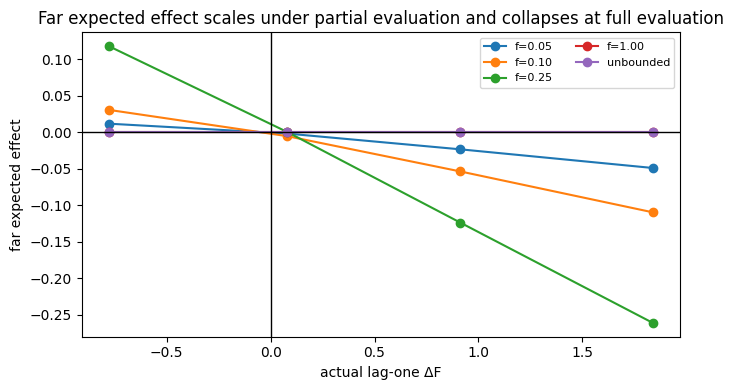

{'label': 'Ch25 canonical audit',
 'source': 'canonical research artifact',
 'observed': {'supported_regime': 'occupied_neighbors = 1',
  'hard_full_controls_checked': 10750,
  'hard_zero_status': 'ASSERTED_ZERO_FAILURES',
  'low_budget_status': 'SUPPORTED',
  'low_budget_fits': {'f=0.05': {'beta': 0.025090131345602402,
    'relative_residual': 0.1256404801713044,
    'beta_over_f': 0.501802626912048},
   'f=0.10': {'beta': 0.05710454463812957,
    'relative_residual': 0.0991670205876477,
    'beta_over_f': 0.5710454463812956},
   'f=0.25': {'beta': 0.14219886777379342,
    'relative_residual': 0.025873265410733017,
    'beta_over_f': 0.5687954710951737}},
  'extreme_ratio_status': 'UNRESOLVED',
  'extreme_ratios': {'f=0.05': -4.145023715213438,
   'f=0.10': -3.5392194853490384,
   'f=0.25': -2.214602750781784},
  'fcp0_f50_far_symdiff': 0.4828888888888888,
  'fcp0_f50_E_far': -0.013038184328936178,
  'fcp_minus1_f50_far_symdiff': 0.4464769647696477,
  'fcp_minus1_f50_E_far': 0.2127208

In [3]:
support = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-01-site-support.json")
sweep = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-02-budget-sweep.json")
classes = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-03-class-summaries.json")
low = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-04-low-budget-linearity.json")
ratio = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-05-extreme-ratio.json")
fcp0 = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-06-fcp0-composition-control.json")
zero = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-08-full-evaluation-hard-zero.json")
verdict = load_json("research/digital-life/ch25-finite-budget-redistribution-v1/stage-09-verdict.json")
for arm in ["f=1.00", "unbounded"]:
    for level in ["-1", "0", "1", "2"]:
        assert abs(zero[arm][level]["E_far"]["mean"]) <= 1e-12
        assert abs(zero[arm][level]["far_symdiff"]["mean"]) <= 1e-12
fractions = ["f=0.05", "f=0.10", "f=0.25", "f=1.00", "unbounded"]
fig, ax = plt.subplots(figsize=(7,4))
for f in fractions:
    xs = [classes[f][k]["actual_deltaF"]["mean"] for k in ["-1","0","1","2"]]
    ys = [classes[f][k]["E_far"]["mean"] for k in ["-1","0","1","2"]]
    ax.plot(xs, ys, marker="o", label=f)
ax.axhline(0, color="black", lw=1); ax.axvline(0, color="black", lw=1)
ax.set(title="Far expected effect scales under partial evaluation and collapses at full evaluation", xlabel="actual lag-one ΔF", ylabel="far expected effect")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "ch25-final-synthesis-budget-coupling.png", bbox_inches="tight"); plt.show()
audit("Ch25 canonical audit", {
    "supported_regime": support["supported_regime"],
    "hard_full_controls_checked": sweep["hard_full_evaluation_controls_checked"],
    "hard_zero_status": "ASSERTED_ZERO_FAILURES",
    "low_budget_status": low["status"],
    "low_budget_fits": {f: {"beta": low["fractions"][f]["beta_through_origin"], "relative_residual": low["fractions"][f]["relative_residual"], "beta_over_f": low["fractions"][f]["beta_through_origin"] / float(f.split("=")[1])} for f in ["f=0.05", "f=0.10", "f=0.25"]},
    "extreme_ratio_status": ratio["status"],
    "extreme_ratios": {f: ratio["fractions"][f]["ratio"] for f in ["f=0.05", "f=0.10", "f=0.25"]},
    "fcp0_f50_far_symdiff": fcp0["f=0.50"]["far_symdiff"]["mean"],
    "fcp0_f50_E_far": fcp0["f=0.50"]["E_far"]["mean"],
    "fcp_minus1_f50_far_symdiff": classes["f=0.50"]["-1"]["far_symdiff"]["mean"],
    "fcp_minus1_f50_E_far": classes["f=0.50"]["-1"]["E_far"]["mean"],
    "overall_status": verdict["overall_status"],
}, source="canonical research artifact")


## Mechanism synthesis

LOCAL INTERVENTION -> LOCAL FRONTIER CHANGE -> FINITE SLOT BUDGET -> NEAR SLOT REALLOCATION -> EQUAL-AND-OPPOSITE FAR SLOT REALLOCATION -> EXPECTED CONSTRUCTION REDISTRIBUTION.

No spatial signal travels outside the one-step causal cone. The coupling is through the shared finite allocation rule.

## Provenance

Current local book chapter: `content/books/digital-life/25-how-does-finite-computation-create-non-local-coupling/index.md`

Research script: `ch25_digital_crystal_finite_budget_redistribution_v1.py`

Canonical artifact: `research/digital-life/ch25-finite-budget-redistribution-v1/`

Notebook figures: `ch25-final-synthesis-budget-coupling.png`

Execution mode: quick assertion check + canonical-artifact-audit

## Claim Ledger

ASSERTION: fixed equal B conserves evaluation slots; full and unbounded evaluation have zero far selector displacement and zero far expected effect.

SUPPORTED: low-budget scaling law for f=.05, .10, .25.

UNRESOLVED: simple -2 extreme FCP ratio calibration.

SUPPORTED: candidate churn is distinct from signed expected construction effect.

UNTESTED: Chapter 26 and appendix claims.
